In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns       
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('../artifacts/raw/data.csv')

df.head()

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low


In [28]:
df.shape

(100000, 15)

In [ ]:
df.describe()

,Timestamp,Machine_ID,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2024-02-04 17:19:30,25.499330,60.041458,2.549959,5.745929,25.555620,2.493418,5.008806,275.916324,0.499385,7.504100
min,2024-01-01 00:00:00,1.000000,30.000138,0.100011,1.500183,1.000025,0.000026,0.000449,50.000375,0.000003,0.000112
25%,2024-01-18 08:39:45,13.000000,45.031596,1.323214,3.627318,13.355118,1.245026,2.521591,162.873618,0.248166,3.750148
50%,2024-02-04 17:19:30,25.000000,60.033597,2.549441,5.755460,25.536079,2.487667,5.003569,276.648922,0.499209,7.504145
75%,2024-02-22 01:59:15,38.000000,74.967217,3.776459,7.860267,37.796372,3.741252,7.506127,388.812761,0.748810,11.273189
max,2024-03-10 10:39:00,50.000000,89.998979,4.999974,9.999889,49.999917,4.999975,9.999900,499.996768,0.999978,14.999869
std,NaN,14.389439,17.323238,1.414127,2.451271,14.120758,1.443273,2.883666,130.096892,0.288814,4.335896


In [5]:
df.isnull().sum()

Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
dtype: int64

In [6]:
df.dtypes

Timestamp                            str
Machine_ID                         int64
Operation_Mode                       str
Temperature_C                    float64
Vibration_Hz                     float64
Power_Consumption_kW             float64
Network_Latency_ms               float64
Packet_Loss_%                    float64
Quality_Control_Defect_Rate_%    float64
Production_Speed_units_per_hr    float64
Predictive_Maintenance_Score     float64
Error_Rate_%                     float64
Efficiency_Status                    str
dtype: object

### Data Preprocessing

In [ ]:
df["Timestamp"]=pd.to_datetime(df["Timestamp"],errors='coerce')

In [13]:
categorical_cols=["Operation_Mode","Efficiency_Status"]

for col in categorical_cols:
    df[col]=df[col].astype('category')

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Timestamp                      100000 non-null  datetime64[us]
 1   Machine_ID                     100000 non-null  int64         
 2   Operation_Mode                 100000 non-null  category      
 3   Temperature_C                  100000 non-null  float64       
 4   Vibration_Hz                   100000 non-null  float64       
 5   Power_Consumption_kW           100000 non-null  float64       
 6   Network_Latency_ms             100000 non-null  float64       
 7   Packet_Loss_%                  100000 non-null  float64       
 8   Quality_Control_Defect_Rate_%  100000 non-null  float64       
 9   Production_Speed_units_per_hr  100000 non-null  float64       
 10  Predictive_Maintenance_Score   100000 non-null  float64       
 11  Error_Rate_%

### EDA

In [17]:
numeric_cols=df.select_dtypes(include=np.number).columns.tolist()   

numeric_cols


['Machine_ID',
 'Temperature_C',
 'Vibration_Hz',
 'Power_Consumption_kW',
 'Network_Latency_ms',
 'Packet_Loss_%',
 'Quality_Control_Defect_Rate_%',
 'Production_Speed_units_per_hr',
 'Predictive_Maintenance_Score',
 'Error_Rate_%']

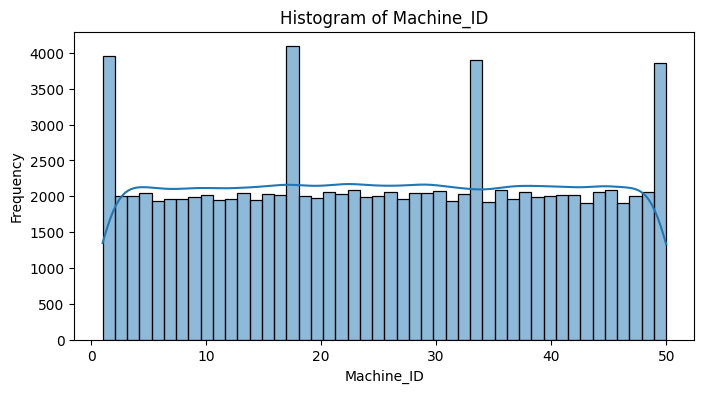

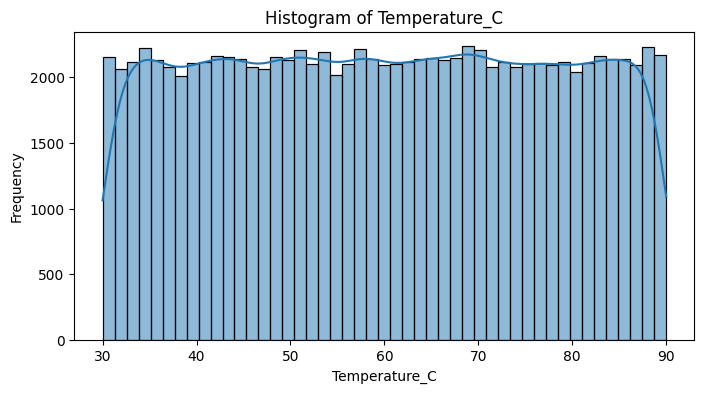

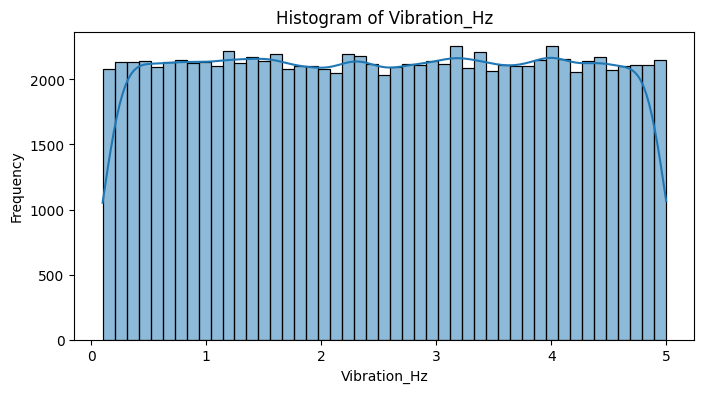

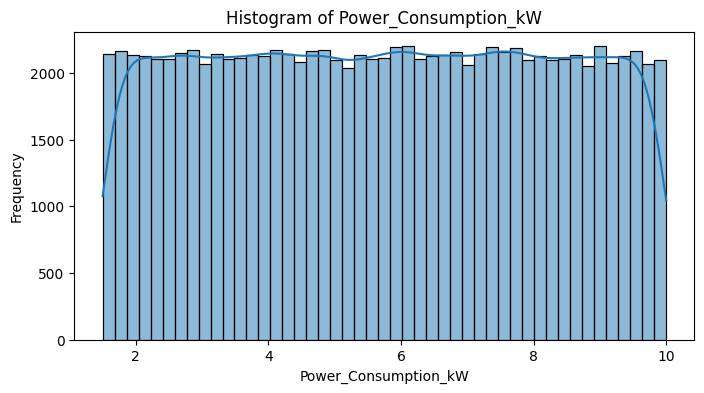

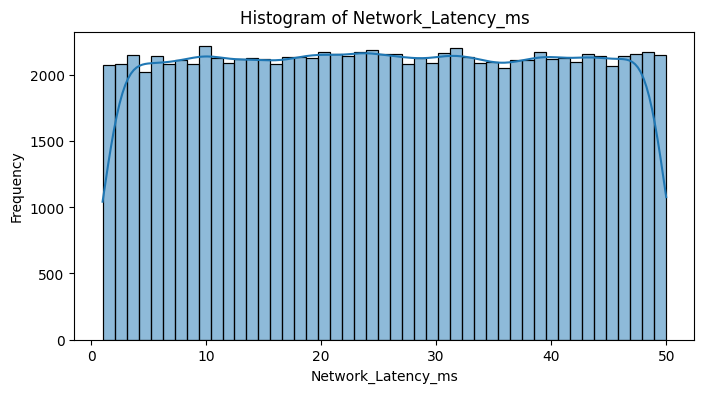

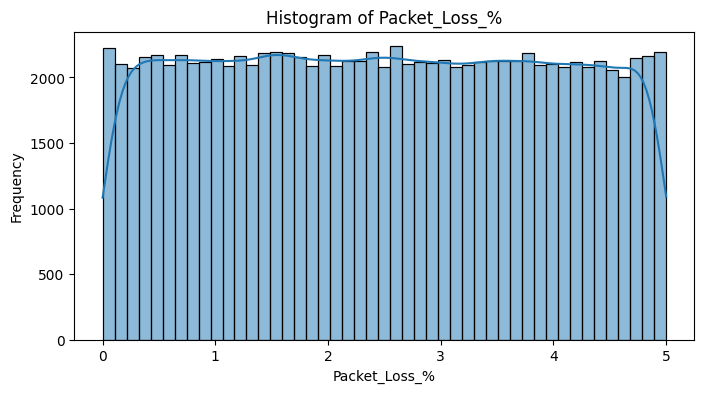

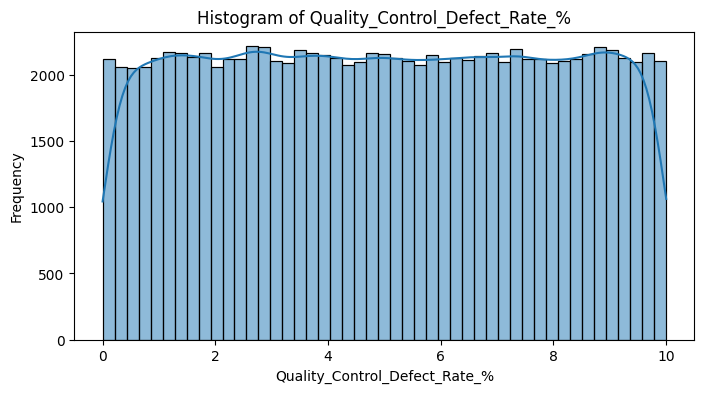

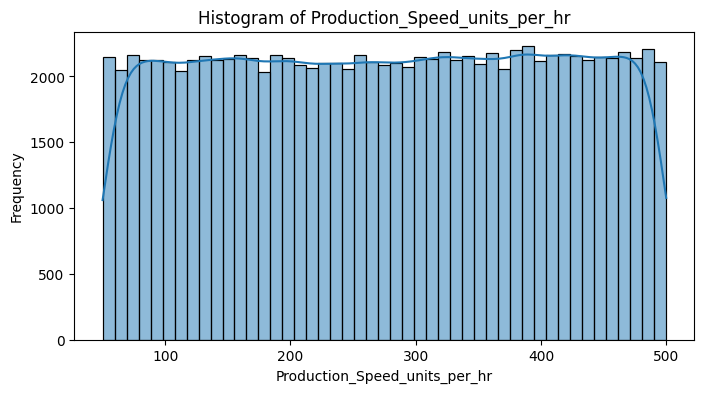

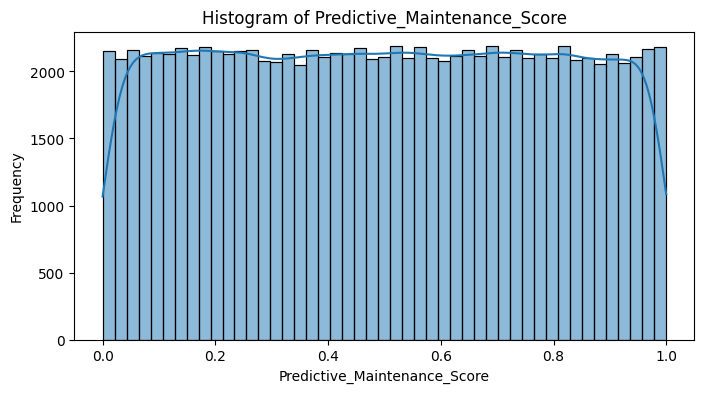

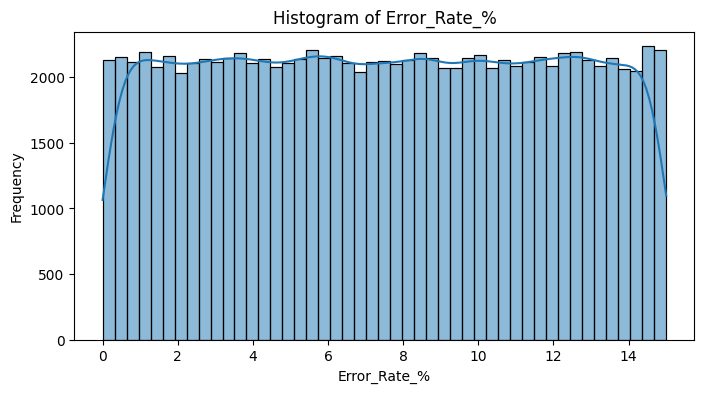

In [18]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col],kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

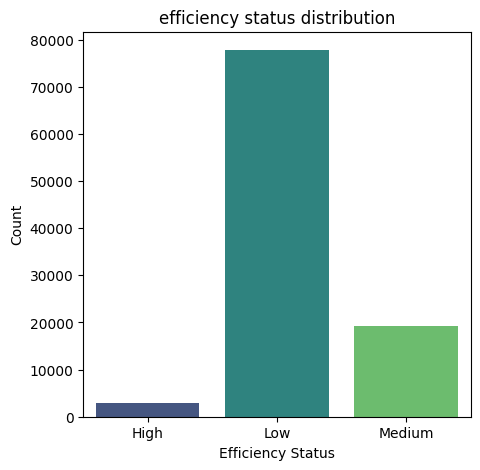

In [22]:
plt.figure(figsize=(5,5))
sns.countplot(x="Efficiency_Status", data=df, palette="viridis")
plt.title("efficiency status distribution")
plt.xlabel("Efficiency Status")
plt.ylabel("Count")     
plt.show()

### feature engineering

In [23]:
df.head()

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low


In [24]:
df["year"]=df["Timestamp"].dt.year
df["month"]=df["Timestamp"].dt.month    
df["day"]=df["Timestamp"].dt.day    
df["hour"]=df["Timestamp"].dt.hour

In [26]:
df.drop(columns=["Timestamp"], inplace=True)

In [27]:
df.drop(columns=["Machine_ID"], inplace=True)

In [29]:
from sklearn.preprocessing import LabelEncoder

labelencoder=LabelEncoder()

In [41]:
df["Efficiency_target"]=labelencoder.fit_transform(df["Efficiency_Status"])

df["Operation_Mode"] = labelencoder.fit_transform(df["Operation_Mode"])

In [31]:
df["Efficiency_target"].value_counts()

Efficiency_target
1    77825
2    19189
0     2986
Name: count, dtype: int64

In [42]:
df.columns

Index(['Operation_Mode', 'Temperature_C', 'Vibration_Hz',
       'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%',
       'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
       'Predictive_Maintenance_Score', 'Error_Rate_%', 'Efficiency_Status',
       'year', 'month', 'day', 'hour', 'Efficiency_target'],
      dtype='str')

In [46]:
features = [
    'Operation_Mode', 'Temperature_C', 'Vibration_Hz',
       'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%',
       'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
       'Predictive_Maintenance_Score', 'Error_Rate_%', 
       'year', 'month', 'day', 'hour']

In [47]:
X = df[features]
y = df["Efficiency_target"]

In [39]:
X.dtypes

Operation_Mode                   category
Temperature_C                     float64
Vibration_Hz                      float64
Power_Consumption_kW              float64
Network_Latency_ms                float64
Packet_Loss_%                     float64
Quality_Control_Defect_Rate_%     float64
Production_Speed_units_per_hr     float64
Predictive_Maintenance_Score      float64
Error_Rate_%                      float64
Efficiency_Status                category
year                                int32
month                               int32
day                                 int32
hour                                int32
dtype: object

In [40]:
df["Operation_Mode"].value_counts()

Operation_Mode
Active         70054
Idle           20057
Maintenance     9889
Name: count, dtype: int64

In [48]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [49]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X_scaled,y, test_size=0.2 , random_state=42 , stratify=y)

In [50]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=42,max_iter=1000)
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [51]:
y_pred = clf.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score , classification_report


print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.91655
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       597
           1       0.95      0.96      0.95     15565
           2       0.80      0.76      0.78      3838

    accuracy                           0.92     20000
   macro avg       0.86      0.85      0.86     20000
weighted avg       0.91      0.92      0.92     20000



In [54]:
### Permutation imprtance

from sklearn.inspection import permutation_importance

result = permutation_importance(clf , X_test , y_test , n_repeats=10 , random_state=42 , n_jobs=-1)


importance_df = pd.DataFrame({
    'Feature' : features,
    'Importances' : result.importances_mean
})
importance_df.sort_values(by='Importances', ascending=False)

,Feature,Importances
9,Error_Rate_%,0.234895
7,Production_Speed_units_per_hr,0.117720
4,Network_Latency_ms,0.000235
6,Quality_Control_Defect_Rate_%,0.000150
3,Power_Consumption_kW,0.000150
13,hour,0.000145
1,Temperature_C,0.000075
8,Predictive_Maintenance_Score,0.000015
2,Vibration_Hz,0.000005
10,year,0.000000
